# Comparing enrichment-score methods on scRNA-seq

`omicverse.es` (`ov.es`) ships GPU-accelerated implementations of 11 enrichment-score (ES) algorithms. They cover the spectrum from rank-based recovery curves (`aucell`, `gsea`, `gsva`) to linear regression (`ulm`, `mlm`, `waggr`), over-representation tests (`ora`), reference statistics (`zscore`), regulon-style activity (`viper`), and gradient-boosted decision trees (`mdt`, `udt`).

Each method assigns a different kind of score:

| method | output | family |
|--------|--------|--------|
| `aucell` | recovery-curve AUC | rank-based |
| `gsea`   | enrichment score (running-sum) | rank-based |
| `gsva`   | KS-style running statistic | rank-based |
| `ulm`    | regression coefficient | linear |
| `mlm`    | multivariate regression coefficient | linear |
| `waggr`  | weighted aggregate | linear |
| `ora`    | log-odds ratio | over-representation |
| `zscore` | normalised mean | reference-based |
| `viper`  | aREA score | regulon-based |
| `mdt`    | feature importance (multivariate GBDT) | tree-based |
| `udt`    | $R^2$ (univariate GBDT) | tree-based |

This notebook runs every method on the same pancreatic-endocrinogenesis dataset and the same two gene sets, all on GPU, then plots the scores side-by-side on the UMAP so you can see how each method paints the same biological signal.

## Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import time
import omicverse as ov
import matplotlib.pyplot as plt

ov.style()

🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.3rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## Load the pancreatic-endocrinogenesis dataset

We reuse the same dataset and gene sets as the [AUCell tutorial](../t_aucell.ipynb): the embryonic mouse pancreas single-cell atlas from `scvelo`. The data already ships with a precomputed UMAP, so we can plot any per-cell score on it directly.

In [2]:
adata = ov.datasets.pancreatic_endocrinogenesis()
adata

⚠️ File ./data/endocrinogenesis_day15.h5ad already exists
 Loading data from ./data/endocrinogenesis_day15.h5ad


✅ Successfully loaded: 3696 cells × 27998 genes


AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced'
    obsp: 'distances', 'connectivities'

In [3]:
adata.var['robust'] = True
adata = ov.pp.preprocess(adata, target_sum=1e4)
adata.X.max()

🔍 [2026-05-17 21:22:05] Running preprocessing in 'cpu' mode...
Begin robust gene identification


    After filtration, 17750/27998 genes are kept.
    Among 17750 genes, 16426 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson



🔍 Count Normalization:
   Target sum: 10000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2
   ⚠️ Excluding 1 highly-expressed genes from normalization computation
   Excluded genes: ['Ghrl']



✅ Count Normalization Completed Successfully!
   ✓ Processed: 3,696 cells × 16,426 genes
   ✓ Runtime: 0.25s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 2,000
   Theta (overdispersion): 100



✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 2,000 highly variable genes out of 16,426 total (12.2%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'highly_variable_nbatches': Int vector (adata.var)
     • 'highly_variable_intersection': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'residual_variances': Float vector (adata.var)
    Time to analyze data in cpu: 1.44 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw counts layer (adata.layers)
    End of size normalization: shiftlog and HVGs selection pearson

╭─ SUMMARY: preprocess ───────────────────

8.060051

## Load the GO Biological Process gene sets

We use the GO Biological Process 2021 collection (same as the AUCell tutorial).

In [4]:
pathway_dict = ov.utils.geneset_prepare(
    'genesets/GO_Biological_Process_2021.txt',
    organism='Mouse',
)
print(f'Loaded {len(pathway_dict)} pathways')

Loaded 6036 pathways


Pick two representative pathways for the comparison: a generic *response to vitamin* signature and the more specific *response to vitamin D* — both feature in the AUCell tutorial.

In [5]:
target_pathways = [
    'response to vitamin (GO:0033273)',
    'response to vitamin D (GO:0033280)',
]
signatures = {p: pathway_dict[p] for p in target_pathways}
for k, v in signatures.items():
    print(f'{k}: {len(v)} genes')

response to vitamin (GO:0033273): 9 genes
response to vitamin D (GO:0033280): 9 genes


## Run all 11 ES methods on GPU

Every `ov.es` method accepts `engine='auto' | 'cpu' | 'gpu'`. With `engine='gpu'` the kernel runs on the torch GPU port; with `engine='auto'` (default) it picks GPU when available and falls back to CPU otherwise.

We pass `times=1` to `gsea` so it only computes the basic enrichment score on GPU — the permutation-based p-values would require a CPU fallback that adds tens of seconds per cell.

In [6]:
methods = ['aucell', 'gsea', 'gsva', 'ora', 'ulm', 'mlm',
           'zscore', 'waggr', 'viper', 'mdt', 'udt']

scored = adata.copy()
timings = {}

for m in methods:
    func = getattr(ov.es, m)
    kwargs = dict(signatures=signatures, tmin=3, engine='gpu')
    # gsea / waggr take a permutation count for empirical p-values; the
    # GPU port handles only the deterministic statistic, so we pin
    # times=1 to keep these methods on-device.
    if m in ('gsea', 'waggr'):
        kwargs['times'] = 1
    elif m == 'udt':
        kwargs['n_estimators'] = 10
    t0 = time.time()
    func(scored, **kwargs)
    timings[m] = time.time() - t0

for m, t in timings.items():
    print(f'  {m:7s}  {t:6.2f} s')


╭─ SUMMARY: ov.es.aucell ────────────────────────────────────────────╮
│  Duration: 0.5884s                                                 │
│  Shape:    3,696 x 16,426 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ score_aucell (dataframe, 3696x2)                     │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯



╭─ SUMMARY: ov.es.gsea ──────────────────────────────────────────────╮
│  Duration: 0.3999s                                                 │
│  Shape:    3,696 x 16,426 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ padj_gsea (dataframe, 3696x2)                        │
│           │ ✚ score_gsea (dataframe, 3696x2)                       │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯



╭─ SUMMARY: ov.es.gsva ──────────────────────────────────────────────╮
│  Duration: 3.9097s                                                 │
│  Shape:    3,696 x 16,426 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ score_gsva (dataframe, 3696x2)                       │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯



╭─ SUMMARY: ov.es.ora ───────────────────────────────────────────────╮
│  Duration: 0.3493s                                                 │
│  Shape:    3,696 x 16,426 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ padj_ora (dataframe, 3696x2)                         │
│           │ ✚ score_ora (dataframe, 3696x2)                        │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯



╭─ SUMMARY: ov.es.ulm ───────────────────────────────────────────────╮
│  Duration: 0.2769s                                                 │
│  Shape:    3,696 x 16,426 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ padj_ulm (dataframe, 3696x2)                         │
│           │ ✚ score_ulm (dataframe, 3696x2)                        │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


...


╭─ SUMMARY: ov.es.zscore ────────────────────────────────────────────╮
│  Duration: 0.2768s                                                 │
│  Shape:    3,696 x 16,426 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ padj_zscore (dataframe, 3696x2)                      │
│           │ ✚ score_zscore (dataframe, 3696x2)                     │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯



╭─ SUMMARY: ov.es.waggr ─────────────────────────────────────────────╮
│  Duration: 0.2741s                                                 │
│  Shape:    3,696 x 16,426 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ padj_waggr (dataframe, 3696x2)                       │
│           │ ✚ score_waggr (dataframe, 3696x2)                      │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯



╭─ SUMMARY: ov.es.viper ─────────────────────────────────────────────╮
│  Duration: 0.5492s                                                 │
│  Shape:    3,696 x 16,426 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ padj_viper (dataframe, 3696x2)                       │
│           │ ✚ score_viper (dataframe, 3696x2)                      │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯



╭─ SUMMARY: ov.es.mdt ───────────────────────────────────────────────╮
│  Duration: 19.8362s                                                │
│  Shape:    3,696 x 16,426 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ score_mdt (dataframe, 3696x2)                        │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯



╭─ SUMMARY: ov.es.udt ───────────────────────────────────────────────╮
│  Duration: 3.5285s                                                 │
│  Shape:    3,696 x 16,426 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ score_udt (dataframe, 3696x2)                        │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
  aucell     0.59 s
  gsea       0.40 s
  gsva       3.91 s
  ora        0.35 s
  ulm        0.28 s
  mlm        0.30 s
  zscore     0.28 s
  waggr      0.28 s
  viper      0.55 s
  mdt       19.84 s
  udt        3.53 s


## Visualise: each method, side-by-side on the UMAP

Each method writes its scores to `scored.obsm[f'score_{method}']` as a `DataFrame`. We move them onto `scored.obs` columns and plot one UMAP per (method × pathway) panel through `ov.pl.umap`. The first row is *response to vitamin*; the second row is *response to vitamin D*.

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False
X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False
X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False
X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False
X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False
X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False
X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False
X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False
X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False
X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False
X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False
X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False
X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False
X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False
X_umap converted to UMAP

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False
X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


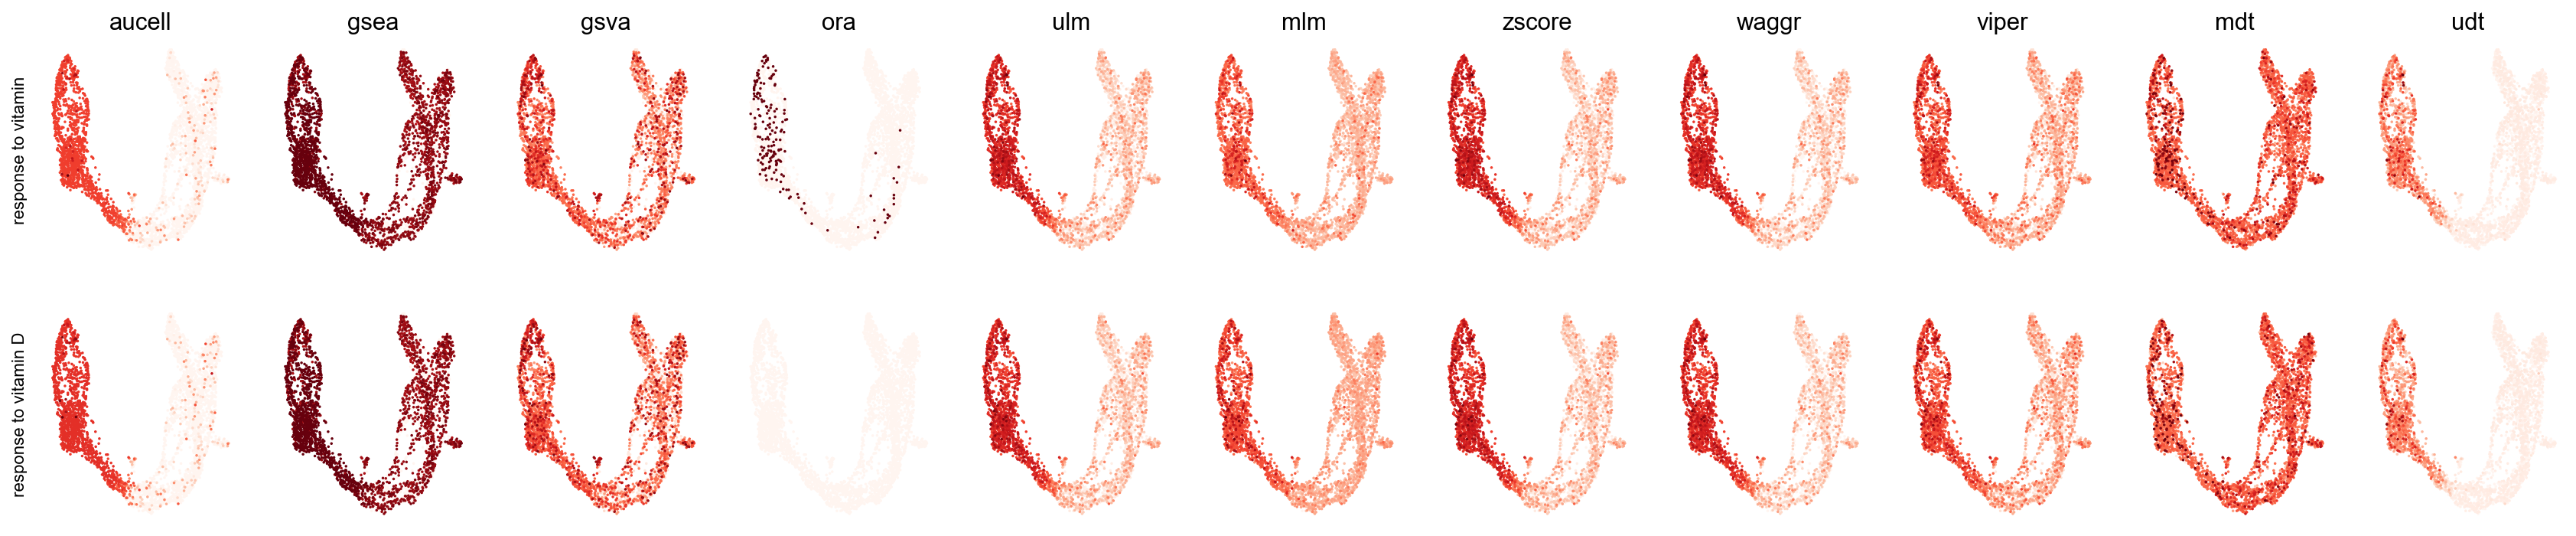

In [7]:
# Stage each method's per-pathway scores as obs columns for plotting.
for m in methods:
    df = scored.obsm[f'score_{m}']
    for p in target_pathways:
        if p in df.columns:
            scored.obs[f'{m}__{p}'] = df[p].astype(float).values

n_methods = len(methods)
fig, axes = plt.subplots(
    nrows=len(target_pathways), ncols=n_methods,
    figsize=(2.4 * n_methods, 2.6 * len(target_pathways)),
)
for row, pathway in enumerate(target_pathways):
    for col, m in enumerate(methods):
        ax = axes[row, col] if len(target_pathways) > 1 else axes[col]
        key = f'{m}__{pathway}'
        ov.pl.umap(
            scored, color=key, cmap='Reds', show=False, ax=ax,
            colorbar_loc=None, frameon=False, size=10,
            title=m if row == 0 else '',
        )

# Add row labels (pathway names) via figure-level text to the left of the
# first column — set_ylabel doesn't show with frameon=False.
for row, pathway in enumerate(target_pathways):
    ax = axes[row, 0] if len(target_pathways) > 1 else axes[0]
    short = pathway.split(' (GO:')[0]
    pos = ax.get_position()
    fig.text(
        pos.x0 - 0.005, pos.y0 + pos.height / 2,
        short, rotation=90, va='center', ha='right', fontsize=10,
    )

plt.show()

## What the comparison shows

- **Rank-based methods** (`aucell`, `gsea`, `gsva`) tend to highlight similar cell populations because they all reward gene-set members appearing early in the per-cell expression ranking.
- **Linear methods** (`ulm`, `mlm`, `waggr`) produce smoother gradients — they integrate over the entire gene set rather than concentrating on the top ranks.
- **`ora`** is the most binary: it tests whether the signature is over-represented among the cell's expressed genes via the hypergeometric distribution.
- **`zscore`** centres each cell's score against a per-feature reference distribution, so the contrast between populations stands out.
- **`viper`** uses a regulon-style aREA score with optional pleiotropy correction.
- **`mdt` / `udt`** are tree-based — `udt` reports per-signature $R^2$ from a univariate GBDT, and `mdt` reports the feature importance of each signature within a multivariate GBDT against all signatures.

All eleven kernels run on the same GPU device with a single `engine='gpu'` flag; the timings printed above show wall-time on PBMC-scale gene-set screens. For deeper benchmarks see the [GPU support overview](../../GPU_supported_registry_functions.md).